<a href="https://colab.research.google.com/github/chayan141/ML-DL-Projects/blob/main/Extensive_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Naive Models
Use Case: Baseline forecasting for stable, non-trending data.
When to Use: When data is irregular/noisy or for simple benchmarks (e.g., constant demand forecasting).

2. Moving Average (MA) / Weighted Moving Average (WMA)
Use Case: Smoothing short-term fluctuations in stable data.
When to Use: Short-term forecasts with no clear trend/seasonality (e.g., daily sales, stock price smoothing).

3. Exponential Smoothing (ES)

  Simple ES: Stationary data with no trend/seasonality (e.g., stable product demand).

  Holt’s Linear Trend: Data with linear trends (e.g., growing sales).

  Holt-Winters: Data with trends and seasonality (e.g., monthly retail sales with holiday peaks).

  When to Use: Business forecasting with trends/seasonality.

4. ARIMA / SARIMA
Use Case: Linear, stationary/near-stationary data, with or without seasonality.
When to Use: Economic indicators, stock prices, or seasonal data (e.g., quarterly GDP, energy consumption).

5. State Space Models (e.g., Kalman Filter)
Use Case: Noisy, dynamic systems requiring real-time updates.
When to Use: Sensor data, navigation, or real-time tracking (e.g., GPS trajectories, stock price tracking).

6. Prophet
Use Case: Business data with seasonality, holidays, or irregular patterns.
When to Use: E-commerce sales, website traffic, or marketing campaigns with holiday effects.

7. Recurrent Neural Networks (RNN) / LSTM
Use Case: Complex, non-linear patterns with long-term dependencies.
When to Use: Stock market prediction, IoT sensor data, or speech recognition.

8. Transformer-Based Models (e.g., Temporal Fusion Transformer, Informer)
Use Case: Multivariate, long-horizon forecasting with complex dependencies.
When to Use: Supply chain demand, multi-region weather, or financial portfolio forecasting.

9. Gaussian Processes (GP)
Use Case: Small datasets needing uncertainty estimates.
When to Use: Medical time series, environmental modeling, or rare event forecasting.

10. Hybrid Models
Use Case: Complex data with linear and non-linear components.
When to Use: Financial markets or energy demand with external covariates (e.g., stock prices with economic indicators).

# Stationarity in Data

Stationary data is a time series where statistical properties like mean, variance, and autocorrelation remain constant over time. It lacks trends (consistent upward/downward movement) and seasonality (repeating patterns).

Non stationary data exhibits trends, seasonality or chenging variance (Stock price).

Making Non Stationary data into stationary:
1. Differencing
2. Log Transform (To stabilize variance)
3. Detrending
4. Box Cox Transformation

Models like prophet, LSTMs, or Transformers can handle non stationary data directly.

Non Stationary data causes models to overfit past patterns, leading to poor predictions.

Stationarity Check:

Augmented Dickeyfuller test (Test for Unit Root):

Null Hypothesis: Data is non stationary.

Alternate Hypothesis: Data is stationary.
if p-value < 0.05, reject the null hypothesis (data is stationary)

KPSS Test: Null hypothesis is data is stationary.

ACF/PACF Plots: Stationary data shows autocorrelation that decays quickly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

# Set random seed for reproducibility
np.random.seed(42)

# Create a sample non-stationary dataset (trend + seasonality + noise)
n = 100
time = np.arange(n)
trend = 0.5 * time  # Linear trend
seasonality = 10 * np.sin(2 * np.pi * time / 12)  # Seasonal period of 12
noise = np.random.normal(0, 1, n)  # Random noise
data = trend + seasonality + noise

# Create a DataFrame
df = pd.DataFrame({'value': data}, index=pd.date_range('2023-01-01', periods=n, freq='D'))

In [2]:
# Function to perform ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

In [3]:
# Function to perform KPSS test
def kpss_test(series):
    result = kpss(series, regression='c')
    print('\nKPSS Test:')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] > 0.05 else 'Non-Stationary')

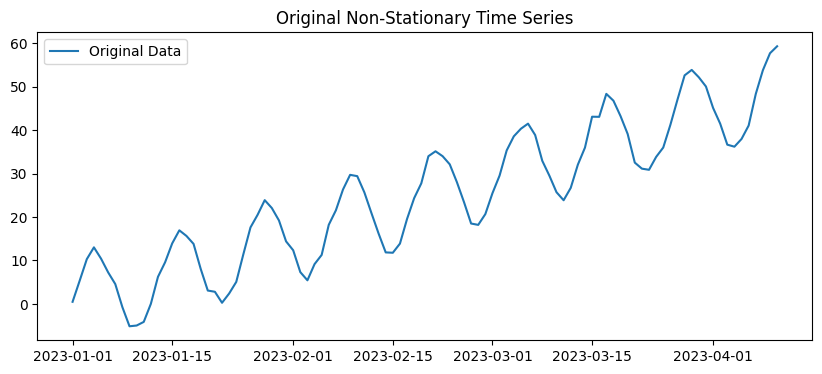

In [4]:
# Step 1: Plot original data
plt.figure(figsize=(10, 4))
plt.plot(df['value'], label='Original Data')
plt.title('Original Non-Stationary Time Series')
plt.legend()
plt.show()

In [5]:
# Step 2: Check stationarity of original data
print("Original Data Stationarity Tests:")
adf_test(df['value'])
kpss_test(df['value'])

Original Data Stationarity Tests:
ADF Test:
ADF Statistic: 0.5035
p-value: 0.9850
Non-Stationary

KPSS Test:
KPSS Statistic: 1.6245
p-value: 0.0100
Non-Stationary


/tmp/ipython-input-3-1520088025.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


ADF : Low p value, data is stationary.
KPSS: Low p-value, data is stationary.

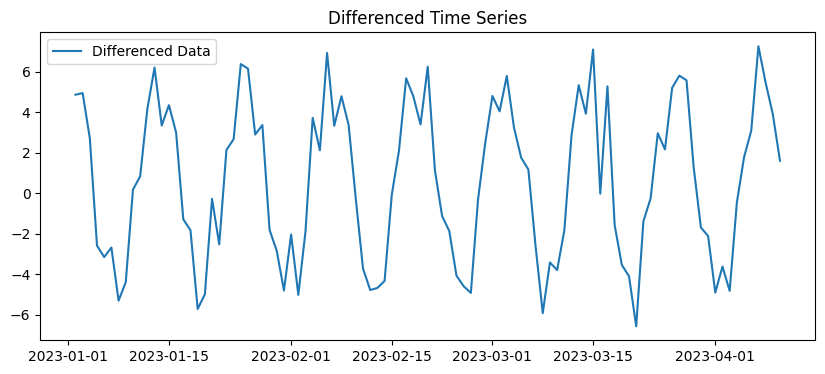

In [6]:
# Step 3: Apply differencing to remove trend
df['diff'] = df['value'].diff().dropna()

# Plot differenced data
plt.figure(figsize=(10, 4))
plt.plot(df['diff'], label='Differenced Data')
plt.title('Differenced Time Series')
plt.legend()
plt.show()

In [7]:
# Step 4: Check stationarity of differenced data
print("\nDifferenced Data Stationarity Tests:")
adf_test(df['diff'].dropna())
kpss_test(df['diff'].dropna())


Differenced Data Stationarity Tests:
ADF Test:
ADF Statistic: -6.7916
p-value: 0.0000
Stationary

KPSS Test:
KPSS Statistic: 0.0258
p-value: 0.1000
Stationary


/tmp/ipython-input-3-1520088025.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c')


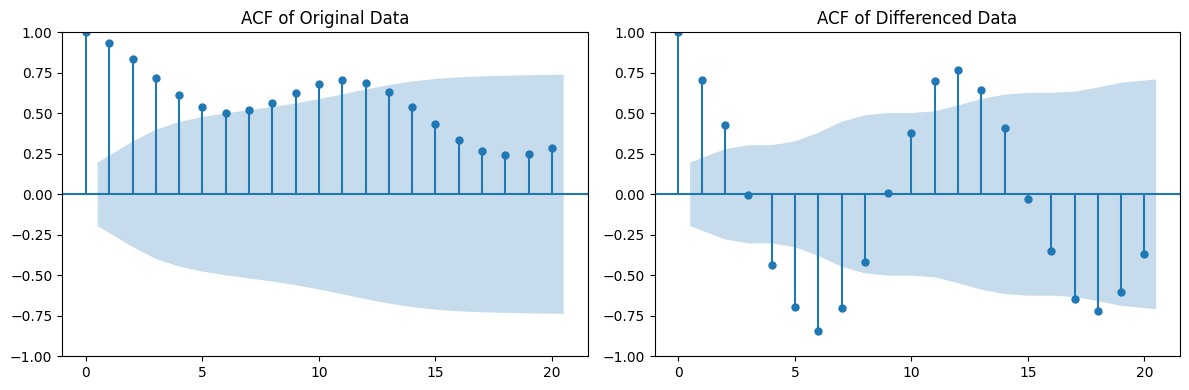

In [8]:
# Step 5: Plot ACF for original and differenced data
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_acf(df['value'], lags=20, ax=plt.gca(), title='ACF of Original Data')
plt.subplot(122)
plot_acf(df['diff'].dropna(), lags=20, ax=plt.gca(), title='ACF of Differenced Data')
plt.tight_layout()
plt.show()

# Autocorrelation and Partial Autocorrelation

To measure the relationship between a time series and its lagged values.

Autocorrelation measures the correlation between a time series and its own lagged values. It quntifies how values at a given time point are related to values at previous time points (lags).

ACF values range from -1 to 1.

Positive ACF: Values at lag $ k $ move in the same direction as current values.

Negative ACF: Values at lag $ k $ move in the opposite directions.

ACF Plot: Shows autocorrelation for different lags. For stationary data, ACF typically decays quickly; for non-stationary data, it decays slowly.

Autocorrelation Used cases:

Identify stationarity. (slow decay suggests non stationarity).

Determine the order of the moving average (MA) of arima model. (Significant lags in ACF indicates MA terms).

Detects seasonality (repeating peaks at regular interval).





Partial Autocorrelation (PACF): Measures the correlation between a time series and its lagged values, after removing the effects of earlier lags.

It ranges from -1 to 1.

Significant PACF at a lag indicates a direct relationaship not explained by earlier lags.

PACF Plots: Shows partial autocorrelations for different lags. For stationary data, significant PACF values typically drop off after a few lags.

Determine the order of the Autoregressive (AR) component in ARIMA (significant lags in PACF indicate AR terms).